In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi gaya visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Library berhasil dimuat.")

Library berhasil dimuat.


In [2]:
# Sesuaikan path dengan lokasi file CSV yang sudah dibersihkan
csv_path = "../dataset/pokemon_cards_dataset_cleaned.csv" 
df = pd.read_csv(csv_path)

print(f"Bentuk dataset: {df.shape[0]} baris dan {df.shape[1]} kolom")
df.head()

Bentuk dataset: 19926 baris dan 10 kolom


,card_id,name,number,rarity,types,set.name,set.release_date,images.large,prices.cardmarket_trend,prices.tcgplayer_variants.holofoil.market
0,hgss4-1,Aggron,1,Rare Holo,Metal,HS—Triumphant,2010/11/03,https://images.pokemontcg.io/hgss4/1_hires.png,3.64,9.80
1,xy5-1,Weedle,1,Common,Grass,Primal Clash,2015/02/04,https://images.pokemontcg.io/xy5/1_hires.png,0.12,NaN
2,pl1-1,Ampharos,1,Rare Holo,Lightning,Platinum,2009/02/11,https://images.pokemontcg.io/pl1/1_hires.png,5.78,32.44
3,dp3-1,Ampharos,1,Rare Holo,Lightning,Secret Wonders,2007/11/01,https://images.pokemontcg.io/dp3/1_hires.png,6.06,42.56
4,det1-1,Bulbasaur,1,Common,Grass,Detective Pikachu,2019/04/05,https://images.pokemontcg.io/det1/1_hires.png,0.63,1.13


In [3]:
# Mengubah kolom tanggal menjadi format datetime dan mengekstrak tahun
df['set.release_date'] = pd.to_datetime(df['set.release_date'], errors='coerce')
df['release_year'] = df['set.release_date'].dt.year

# Memastikan kolom harga bertipe numerik 
df['prices.cardmarket_trend'] = pd.to_numeric(df['prices.cardmarket_trend'], errors='coerce')
df['prices.tcgplayer_variants.holofoil.market'] = pd.to_numeric(df['prices.tcgplayer_variants.holofoil.market'], errors='coerce')

# Mengecek tipe data dan missing values setelah konversi
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19926 entries, 0 to 19925
Data columns (total 11 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   card_id                                    19926 non-null  object        
 1   name                                       19926 non-null  object        
 2   number                                     19926 non-null  object        
 3   rarity                                     19670 non-null  object        
 4   types                                      16848 non-null  object        
 5   set.name                                   19926 non-null  object        
 6   set.release_date                           19926 non-null  datetime64[ns]
 7   images.large                               19926 non-null  object        
 8   prices.cardmarket_trend                    18582 non-null  float64       
 9   prices.tcgplayer_

card_id                                          0
name                                             0
number                                           0
rarity                                         256
types                                         3078
set.name                                         0
set.release_date                                 0
images.large                                     0
prices.cardmarket_trend                       1344
prices.tcgplayer_variants.holofoil.market    12792
release_year                                     0
dtype: int64

C:\Users\THIN 15\AppData\Local\Temp\ipykernel_3724\2299282715.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\THIN 15\AppData\Local\Temp\ipykernel_3724\2299282715.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


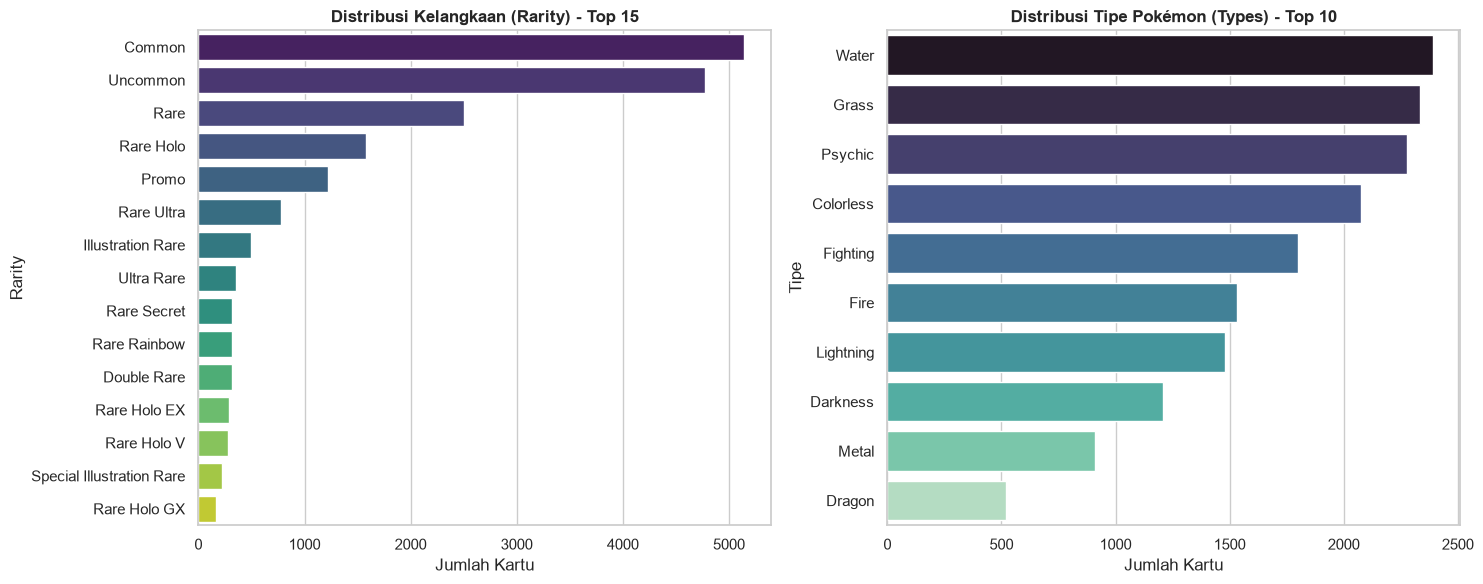

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Distribusi Kelangkaan (Rarity)
sns.countplot(
    y=df['rarity'], 
    order=df['rarity'].value_counts().index[:15], 
    palette="viridis", 
    ax=axes[0]
)
axes[0].set_title("Distribusi Kelangkaan (Rarity) - Top 15", fontweight="bold")
axes[0].set_xlabel("Jumlah Kartu")
axes[0].set_ylabel("Rarity")

# Distribusi Elemen/Tipe (Types)
sns.countplot(
    y=df['types'], 
    order=df['types'].value_counts().index[:10], 
    palette="mako", 
    ax=axes[1]
)
axes[1].set_title("Distribusi Tipe Pokémon (Types) - Top 10", fontweight="bold")
axes[1].set_xlabel("Jumlah Kartu")
axes[1].set_ylabel("Tipe")

plt.tight_layout()
plt.show()

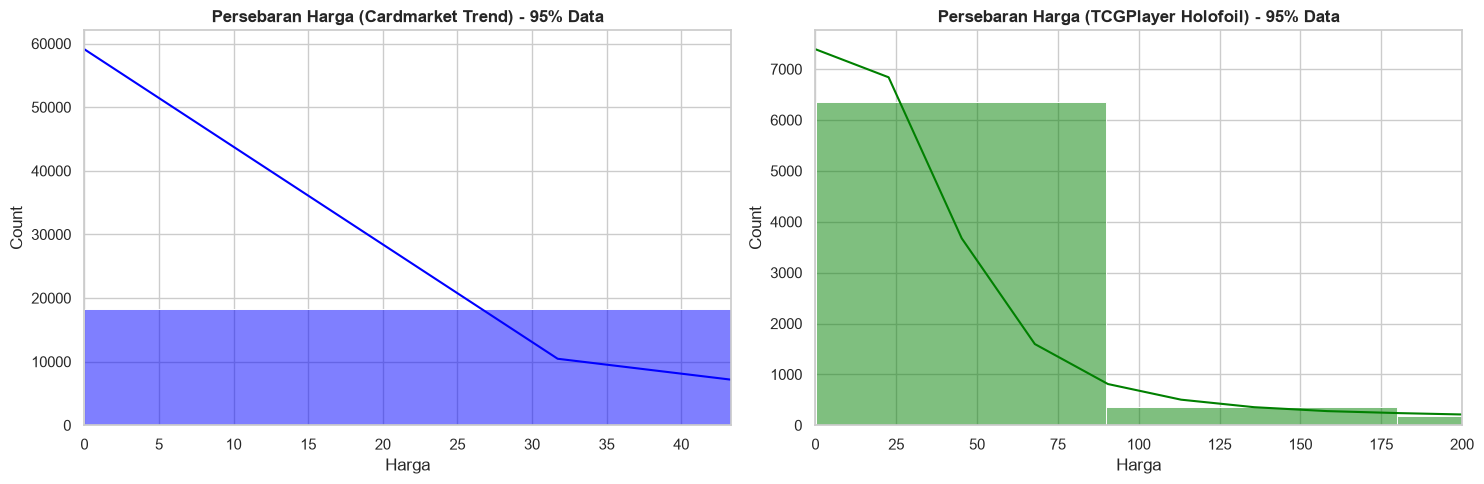

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribusi Harga Cardmarket Trend
sns.histplot(
    df['prices.cardmarket_trend'], 
    bins=50, 
    kde=True, 
    color="blue", 
    ax=axes[0]
)
# Membatasi tampilan sumbu X pada persentil 95 agar outlier ekstrem tidak merusak grafik
axes[0].set_xlim(0, df['prices.cardmarket_trend'].quantile(0.95))
axes[0].set_title("Persebaran Harga (Cardmarket Trend) - 95% Data", fontweight="bold")
axes[0].set_xlabel("Harga")

# Distribusi Harga TCGPlayer Holofoil
sns.histplot(
    df['prices.tcgplayer_variants.holofoil.market'], 
    bins=50, 
    kde=True, 
    color="green", 
    ax=axes[1]
)
axes[1].set_xlim(0, df['prices.tcgplayer_variants.holofoil.market'].quantile(0.95))
axes[1].set_title("Persebaran Harga (TCGPlayer Holofoil) - 95% Data", fontweight="bold")
axes[1].set_xlabel("Harga")

plt.tight_layout()
plt.show()

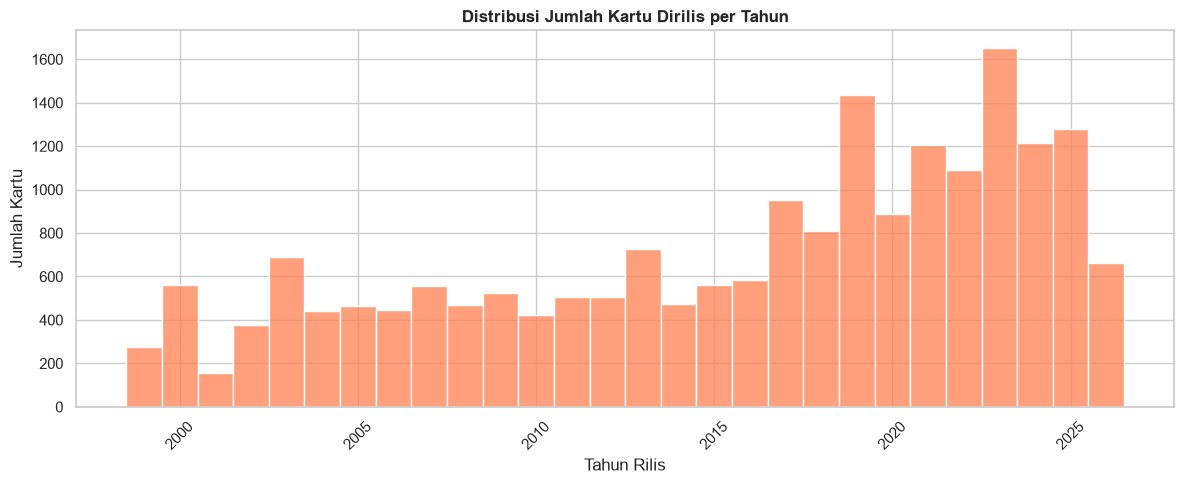

In [6]:
plt.figure(figsize=(12, 5))

# Distribusi Kartu Berdasarkan Tahun Rilis
sns.histplot(
    df['release_year'].dropna(), 
    bins=len(df['release_year'].dropna().unique()), 
    color="coral",
    discrete=True
)
plt.title("Distribusi Jumlah Kartu Dirilis per Tahun", fontweight="bold")
plt.xlabel("Tahun Rilis")
plt.ylabel("Jumlah Kartu")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()